In [8]:
# Installing libraries to clean ship city
!pip install thefuzz
!pip install bharataddress

In [9]:
# IMPORTING IMPORTANT LIBRARIES FOR ANALYSIS
# ===========================================
import pandas as pd
import numpy as np
import re
from rapidfuzz import fuzz, process
from bharataddress import parse
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from matplotlib.ticker import EngFormatter
sns.set_style("whitegrid")

## 1. Load Data
**Load the dataset and understanding it's structure.**


In [10]:
# LOADING DATASET AND MAKING COPY OF RAW DATA
# =======================================================

raw = pd.read_csv('/content/drive/MyDrive/Dataset/Amazon raw data.csv', low_memory=False)
df = raw.copy()
pd.set_option('Display.max_columns', None)


In [11]:
# TOTAL ROWS AND COLUMNS IN DATASET (SHAPE)
row, cols = df.shape

print(f'Total Rows : {row} \nTotal columns {cols}')

Total Rows : 128975 
Total columns 24


In [12]:
# NOT NULL VALUE AND DATA TYPE
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   order_date          128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [13]:
# EXPLORING COLUMNS AVAILABLE IN DATASET
df.columns

Index(['index', 'Order ID', 'order_date', 'Status', 'Fulfilment',
       'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category',
       'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount',
       'ship-city', 'ship-state', 'ship-postal-code', 'ship-country',
       'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

### **Observations on Initial Exploration**
* Dataset has Row : 128975 (total orders) and columns : 24 (total features)

* Columns include : ('index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22') does not follow proper naming convenstion, need to standardize

* Type of information in the dataset (Segmentation)
    * **`ORDER DATA`** (Order ID, Date, Qty, Amount, B2B)
    * **`PRODUCT DATA`** (Style, SKU, Category, Size, Asin)
    * **`SHIPPING DATA`** (Fulfilment, Sales Channel, Ship-service-level, Courier Status, Fulfilled-by)
    * **`Geographical Data`** (ship-city, ship-sate, ship-postal-code, ship-country) and **`others`**

* `Missing values in Columns` - ('fulfilled_by', 'promotion_ids', 'unnamed_22', 'currency', 'amount', 'courier_status', 'ship_country', 'ship_city', 'ship_state', 'ship_postal_code')
* `Incorrect Datatypes in Columns` - (order_date, Ship-postal-code)` has incorrect datatypes



In [14]:
# STANDARDIZING COLUMN NAME
# =============================

df.columns = df.columns.str.strip().str.lower().str.replace(r'[^0-9a-zA-Z]+', '_', regex=True)
print(f'Columns After Standardization : \n{df.columns}')

Columns After Standardization : 
Index(['index', 'order_id', 'order_date', 'status', 'fulfilment',
       'sales_channel', 'ship_service_level', 'style', 'sku', 'category',
       'size', 'asin', 'courier_status', 'qty', 'currency', 'amount',
       'ship_city', 'ship_state', 'ship_postal_code', 'ship_country',
       'promotion_ids', 'b2b', 'fulfilled_by', 'unnamed_22'],
      dtype='object')


##2. Data Quality Assessment

* Evaluating Validity, Uniqueness, Completeness and Consistency to identify data quality issue to ensure analysis accuracy and limitations.


**Approach :**
* Explore Incorrect data types, Format issue, range, valid value
* Explore duplicates orders, Unique values in Target columns (Category, Size, Shipping Adress, Shipping types)
* Define function to calculate missing values and percentage(%), also explore all missing columns
* Explore cancelled orders and feature engineering

###**Validity**
* Explore Incorrect data types, Format issue, range, valid value

In [15]:
# Data types of each columns

print(f'DataTypes of each columns : \n{df.dtypes}')

DataTypes of each columns : 
index                   int64
order_id               object
order_date             object
status                 object
fulfilment             object
sales_channel          object
ship_service_level     object
style                  object
sku                    object
category               object
size                   object
asin                   object
courier_status         object
qty                     int64
currency               object
amount                float64
ship_city              object
ship_state             object
ship_postal_code      float64
ship_country           object
promotion_ids          object
b2b                      bool
fulfilled_by           object
unnamed_22             object
dtype: object


In [16]:
# Descriptive Statistics

df.describe()

,index,qty,amount,ship_postal_code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


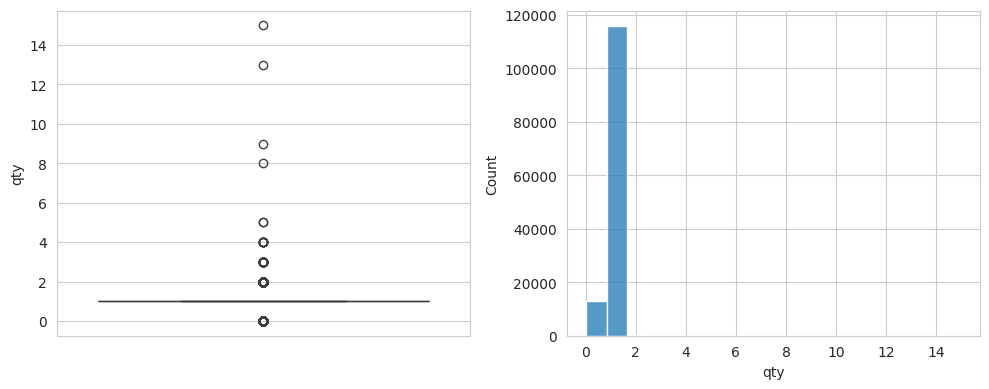

In [17]:
# Plotting quantity to understand distribution and shape
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 4))

ax1 = sns.boxplot(df['qty'], ax=ax1)
ax2 = sns.histplot(df['qty'], ax=ax2)

plt.tight_layout()
plt.show()

In [18]:
# Explore how many orders have more than 2 quantity
print(f'Total Orders count where Quantity > 2 : {df[df['qty'] > 2].shape[0]}')

Total Orders count where Quantity > 2 : 47


In [19]:
quantity_outliers = df[df['qty'] > 2]
quantity_outliers[['order_id', 'category', 'sku', 'qty', 'amount', 'status', 'courier_status', 'b2b']]

,order_id,category,sku,qty,amount,status,courier_status,b2b
937,S02-5278980-4327051,Blouse,BL017-63BLACK,15,NaN,Shipped,Unshipped,False
2107,405-7829062-0073141,kurta,JNE3365-KR-1052-A-S,3,1128.0,Shipped - Returned to Seller,Shipped,False
3289,406-3338330-9401954,Western Dress,JNE3798-KR-M,3,2175.0,Shipped - Delivered to Buyer,Shipped,False
3631,S02-1006261-5356758,kurta,JNE2305-KR-533-L,9,NaN,Shipped,Unshipped,False
3636,S02-6828927-1180856,kurta,JNE2305-KR-533-XXL,13,NaN,Shipped,Unshipped,False
11160,403-4106553-1691525,Set,J0013-SKD-XXXL,5,5495.0,Shipped - Delivered to Buyer,Shipped,True
17338,403-2332292-9207530,kurta,JNE2265-KR-501-XXL,4,1316.0,Shipped - Delivered to Buyer,Shipped,False
19180,407-9962496-1568355,kurta,JNE3291-KR-XL,3,1326.0,Shipped,Shipped,False
20534,406-1124784-1093950,Western Dress,J0341-DR-M,3,2232.0,Shipped - Delivered to Buyer,Shipped,False
23739,407-9225645-2865924,kurta,JNE1951-KR-155-XXXL,3,1104.0,Shipped - Delivered to Buyer,Shipped,True


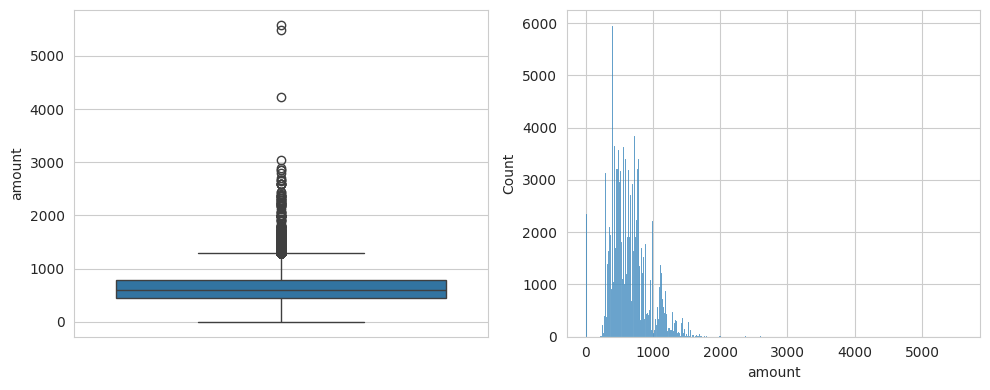

In [20]:
# Plotting Amount to understand distribution and shape
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 4))

ax1 = sns.boxplot(df['amount'], ax=ax1)
ax2 = sns.histplot(df['amount'], ax=ax2)

plt.tight_layout()
plt.show()

In [21]:
print(f'Total Order count where amount > 2000 : {df[df['amount'] > 2000].shape[0]}')

Total Order count where amount > 2000 : 54


In [22]:
amount_outliers = df[df['amount'] > 2000]
amount_outliers[['order_id', 'category', 'sku', 'qty', 'amount', 'status', 'courier_status', 'b2b']]

,order_id,category,sku,qty,amount,status,courier_status,b2b
265,171-6655820-6440356,Set,J0008-SKD-XXL,2,2130.00,Shipped,Shipped,False
647,171-6153595-4758722,Set,J0230-SKD-S,2,2224.00,Shipped,Shipped,False
3289,406-3338330-9401954,Western Dress,JNE3798-KR-M,3,2175.00,Shipped - Delivered to Buyer,Shipped,False
11160,403-4106553-1691525,Set,J0013-SKD-XXXL,5,5495.00,Shipped - Delivered to Buyer,Shipped,True
13698,403-3943362-8896346,Set,J0013-SKD-XXXL,2,2198.00,Shipped - Delivered to Buyer,Shipped,True
16577,405-4362525-1025138,Set,J0238-LCD-XXXL,1,2299.00,Shipped,Shipped,False
17279,404-1362203-3716347,Set,J0230-SKD-M,2,2224.00,Shipped,Shipped,False
17286,404-9390368-1493927,Set,J0230-SKD-M,2,2224.00,Cancelled,Unshipped,False
20534,406-1124784-1093950,Western Dress,J0341-DR-M,3,2232.00,Shipped - Delivered to Buyer,Shipped,False
24494,407-3483041-9133135,Set,SET397-KR-NP -M,0,4235.72,Cancelled,NaN,False


### **Observation on Validity**
* order_date is stored as object and should be converted to datetime for date-based analysis. ship_postal_code is stored as float64 but should be treated as a categorical/string field because postal codes are identifiers, not numerical values.

* No negative values were found in qty. Q1, median and Q3 are all 1, indicating that most orders have a quantity of 1. The maximum quantity is 15 and the distribution is heavily concentrated around 0–2. Further investigation shows only 47 orders having quantity > 2 and when analyzed these orders have valid order information and almost all the orders got shipped/delivered. Therefore these orders are legitimate orders and would not be removed.

* No negative values were found in amount. Q1 amount is 449, median amount is 605 and Q3 is 788, while the maximum is 5,584 (approximately 7.1× Q3). The distribution is concentrated highly within 0-2000 range. Further investigation shows only 54 orders having amount > 2000 when analyzed these orders are mostly shipped/delivered. Therefore these are legitimate orders and would retain rather than removing.

###**Uniqueness**
* Explore duplicates orders, Unique values in Target columns (Category, Size, Shipping Adress, Shipping types)


In [23]:
# Explore duplicate orders

print(f'Fully duplicated rows : {df.duplicated().sum()}')
print(f'Duplicate order_ids : {df.duplicated('order_id').sum()}')

Fully duplicated rows : 0
Duplicate order_ids : 8597


In [24]:
# Exploring duplicate order_ids

df[df.duplicated('order_id', keep=False)].head(10)

,index,order_id,order_date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,unnamed_22
37,37,403-4367956-2849158,25-06-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3787,JNE3787-KR-S,kurta,S,B09RKBXM5B,Shipped,1,INR,487.0,NEW DELHI,DELHI,110092.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
38,38,403-4367956-2849158,20-01-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3543,JNE3543-KR-S,kurta,S,B08HHJP41L,Shipped,1,INR,368.0,NEW DELHI,DELHI,110092.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
61,61,404-2262140-4696366,30-03-2022,Shipped,Amazon,Amazon.in,Expedited,JNE2270,JNE2270-KR-487-A-M,kurta,M,B07H7FZD32,Shipped,1,INR,518.0,NAGPUR,MAHARASHTRA,440022.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
62,62,404-2262140-4696366,25-11-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3579,JNE3579-KR-M,kurta,M,B08QGK2BS2,Shipped,1,INR,295.0,NAGPUR,MAHARASHTRA,440022.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
79,79,408-4069830-3819562,26-12-2022,Shipped,Amazon,Amazon.in,Expedited,SET288,SET288-KR-NP-XXXL,Set,3XL,B09M6STTBC,Shipped,1,INR,684.0,Kolkata,WEST BENGAL,700048.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
80,80,408-4069830-3819562,21-11-2022,Shipped,Amazon,Amazon.in,Expedited,SET394,SET394-KR-NP-XXXL,Set,3XL,B09TH6R8K4,Shipped,1,INR,1281.0,Kolkata,WEST BENGAL,700048.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
81,81,408-4069830-3819562,02-12-2022,Shipped,Amazon,Amazon.in,Expedited,SET397,SET397-KR-NP-XXXL,Set,3XL,B09RKDPH6J,Shipped,1,INR,1186.0,Kolkata,WEST BENGAL,700048.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
105,105,405-5257740-5301158,13-10-2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET154,SET154-KR-NP-XL,Set,XL,B082PXMCZ4,Shipped,1,INR,832.0,ROHTAK,HARYANA,124001.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
106,106,405-5257740-5301158,26-03-2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3439,JNE3439-KR-XL,kurta,XL,B081X4KQ14,Shipped,1,INR,399.0,ROHTAK,HARYANA,124001.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
116,116,403-0104882-7373900,11-08-2022,Cancelled,Amazon,Amazon.in,Expedited,JNE3861,JNE3861-DR-XXL,Western Dress,XXL,B09SDY9GXB,Unshipped,1,INR,791.0,HIMMATNAGAR,Gujarat,383001.0,IN,NaN,False,NaN,NaN


In [25]:
# Explore count of unique values in each columns

print(df.nunique())

index                 128975
order_id              120378
order_date               365
status                    13
fulfilment                 2
sales_channel              2
ship_service_level         2
style                   1377
sku                     7195
category                   9
size                      11
asin                    7190
courier_status             3
qty                       10
currency                   1
amount                  1410
ship_city               8955
ship_state                69
ship_postal_code        9459
ship_country               1
promotion_ids           5787
b2b                        2
fulfilled_by               1
unnamed_22                 1
dtype: int64


In [26]:
target_columns = ['category', 'size', 'fulfilment']

for column in target_columns:
    print(f'Unique Values : {df[column].unique()}')
    print('='*30)

Unique Values : ['Set' 'kurta' 'Western Dress' 'Top' 'Ethnic Dress' 'Bottom' 'Saree'
 'Blouse' 'Dupatta']
Unique Values : ['S' '3XL' 'XL' 'L' 'XXL' 'XS' '6XL' 'M' '4XL' '5XL' 'Free']
Unique Values : ['Merchant' 'Amazon']


In [27]:
# Unique ship states

print(f'Unique Ship States : \n{df['ship_state'].unique()}')

Unique Ship States : 
['MAHARASHTRA' 'KARNATAKA' 'PUDUCHERRY' 'TAMIL NADU' 'UTTAR PRADESH'
 'CHANDIGARH' 'TELANGANA' 'ANDHRA PRADESH' 'RAJASTHAN' 'DELHI' 'HARYANA'
 'ASSAM' 'JHARKHAND' 'CHHATTISGARH' 'ODISHA' 'KERALA' 'MADHYA PRADESH'
 'WEST BENGAL' 'NAGALAND' 'Gujarat' 'UTTARAKHAND' 'BIHAR'
 'JAMMU & KASHMIR' 'PUNJAB' 'HIMACHAL PRADESH' 'ARUNACHAL PRADESH'
 'MANIPUR' 'Goa' 'MEGHALAYA' 'GOA' 'TRIPURA' 'LADAKH' 'DADRA AND NAGAR'
 'SIKKIM' 'Delhi' nan 'ANDAMAN & NICOBAR ' 'Punjab' 'Rajshthan' 'Manipur'
 'rajasthan' 'Odisha' 'NL' 'Bihar' 'MIZORAM' 'punjab' 'New Delhi'
 'Rajasthan' 'Punjab/Mohali/Zirakpur' 'Puducherry' 'delhi' 'RJ'
 'Chandigarh' 'orissa' 'LAKSHADWEEP' 'goa' 'PB' 'APO' 'Arunachal Pradesh'
 'AR' 'Pondicherry' 'Sikkim' 'Arunachal pradesh' 'Nagaland' 'bihar'
 'Mizoram' 'rajsthan' 'Orissa' 'Rajsthan' 'Meghalaya']


In [28]:
# Unique ship cities
print(f'Unique Ship Cities : \n{df['ship_city'].unique()[:200]}')

Unique Ship Cities : 
['MUMBAI' 'BENGALURU' 'NAVI MUMBAI' 'PUDUCHERRY' 'CHENNAI' 'GHAZIABAD'
 'CHANDIGARH' 'HYDERABAD' 'Chennai' 'NOIDA' 'Amravati.' 'GUNTAKAL'
 'JAIPUR' 'NEW DELHI' 'Gurgaon' 'TIRUCHIRAPPALLI' 'pune' 'TEZPUR' 'RANCHI'
 'BILASPUR' 'PUNE' 'GUWAHATI' 'THIRUVARUR' 'LUCKNOW' 'VISAKHAPATNAM'
 'JEYPUR' 'THIRUVANANTHAPURAM' 'GREATER NOIDA' 'JABALPUR' 'KOLKATA'
 'ONGOLE' 'SECUNDERABAD' 'KEWALPUR' 'CUTTACK' 'BADLAPUR' 'dimapur'
 'WARANGAL' 'DHAULPUR' 'Bengaluru' 'NAGPUR' 'THANE' 'Dahod' 'VIJAPURA'
 'bangalore' 'BERHAMPUR' 'HIMMATNAGAR' 'Kolkata' 'DEHRADUN' 'DHARMAPURI'
 'VADODARA' 'CHAVAKKAD' 'PATNA' 'Jammu' 'NARNAUND' 'Ahmedabad' 'AMBARNATH'
 'GWALIOR' 'ROHTAK' 'RAMAGUNDAM' 'PITHORAGARH' 'GUWAHATI, KAMRUP (M)'
 'KOLAR' 'PATIALA' 'REWA' 'BONGAIGAON' 'Chengalpattu' 'PERAMBALUR'
 'VARANASI' 'COIMBATORE' 'CHIRMIRI' 'AZAMGARH' 'KALYAN' 'MYSORE'
 'BARABANKI' 'AMILA' 'VIJAYAWADA' 'RAWAN AMBUJA CEMENT PLANT' 'HERBERTPUR'
 'KALAMASSERY' 'Puri-2' 'TIKABALI' 'BIHARSHARIF' 'PARAVUR' 'BASTI

### **Observations on Uniqueness**
* There are no fully duplicated rows but 8597 orders have duplicate order_ids, further explored and found same order_ids contain different categories, products, sizes and locations so they are not duplicate orders rather they are multi-product orders.
* Ship states have 69 unique state and based on Indian territories there are 36 states (28 States + 8 UT) , further investigation shows ship states has formating issue (abbreviations, uppercase, lowercase, different spellings), should fix this formating issue before state wise analysis
* Ship City shows 8955 unique cities, further investigation shows ship city has format issue (Uppercase, Lowercase, different spellings, Pincode included, State abbrebiation included), which should fix these issues before city wise analysis.

##Completeness - Exploring Missings
* Define function to calculate missing values and percentage(%), also explore all missing columns


In [29]:
# DEFINING FUNCTION TO CHECK MISSING COUNT AND ITS PERCENTAGE IN EACH COLUMN
# ========================================================================

def missing_data(df):
    missing_count = df.isna().sum().sort_values(ascending=False)
    missing_count = missing_count[missing_count != 0]
    missing_perc = (missing_count * 100 / len(df)).round(2)

    return pd.DataFrame({'missing_count': missing_count, 'missing %': missing_perc})

In [30]:
# Calculating Missing vlaues & Missing percentage in each columns

print(f'Missing values : \n{missing_data(df)}')

Missing values : 
                  missing_count  missing %
fulfilled_by              89698      69.55
promotion_ids             49153      38.11
unnamed_22                49050      38.03
currency                   7795       6.04
amount                     7795       6.04
courier_status             6872       5.33
ship_country                 33       0.03
ship_city                    33       0.03
ship_state                   33       0.03
ship_postal_code             33       0.03


In [31]:
# Define target columns to explore missing amount distribution in each
target_columns = ['category', 'size', 'fulfilment']

missing_amount = df[df['amount'].isna()]

for column in target_columns:
    print(round(missing_amount[column].value_counts(normalize=True)*100, 2))
    print('='*30)

category
Set              41.59
kurta            40.54
Western Dress    10.21
Top               5.86
Ethnic Dress      0.85
Blouse            0.58
Bottom            0.26
Saree             0.12
Name: proportion, dtype: float64
size
M       18.20
L       17.09
XL      14.75
S       14.59
XXL     13.21
XS      11.10
3XL      9.80
6XL      0.42
5XL      0.31
Free     0.28
4XL      0.24
Name: proportion, dtype: float64
fulfilment
Amazon      77.73
Merchant    22.27
Name: proportion, dtype: float64


In [32]:
# Explore Fulfilled_by
print(f'Missing Fulfilled_by count : {df['fulfilled_by'].isna().sum()}\n')
print('='*30)
print(f'Distribution of Order fulfilment where Fulfilled_by is missing : \n{df[df['fulfilled_by'].isna()]['fulfilment'].value_counts()}\n')

Missing Fulfilled_by count : 89698

Distribution of Order fulfilment where Fulfilled_by is missing : 
fulfilment
Amazon    89698
Name: count, dtype: int64



In [33]:
# Explore missing unnamed_22

print(f'Distribution of Unname_22 : {df['unnamed_22'].value_counts()}')

Distribution of Unname_22 : unnamed_22
False    79925
Name: count, dtype: int64


In [34]:
# Explore
print(f'Distribution of Order status for missing promotion_ids : \n{df[df['promotion_ids'].isna()]['status'].value_counts(normalize=True).mul(100)}')


Distribution of Order status for missing promotion_ids : 
status
Shipped                          62.883242
Cancelled                        36.695624
Pending                           0.313307
Shipped - Delivered to Buyer      0.077310
Shipping                          0.016276
Shipped - Returned to Seller      0.008138
Shipped - Picked Up               0.004069
Pending - Waiting for Pick Up     0.002034
Name: proportion, dtype: float64


In [35]:
# Explore missing currency and amount

print(f'Currency & Amount combined Missing Count : {((df['currency'].isna()) & (df['amount'].isna())).sum()}')


Currency & Amount combined Missing Count : 7795


In [36]:
# Explore Order status and Courier status for Missing amount

print(f'Distribution of Order Status for missing amount : \n{df[df['amount'].isna()]['status'].value_counts(normalize=True).mul(100)}')
print('='*30)
print(f'Distribution of Courier Status for missing amount : \n{df[df['amount'].isna()]['courier_status'].value_counts(normalize=True).mul(100)}')

Distribution of Order Status for missing amount : 
status
Cancelled                       97.062219
Shipped                          2.668377
Shipped - Delivered to Buyer     0.102630
Shipping                         0.102630
Shipped - Returned to Seller     0.038486
Pending                          0.025657
Name: proportion, dtype: float64
Distribution of Courier Status for missing amount : 
courier_status
Cancelled    97.953458
Unshipped     2.046542
Name: proportion, dtype: float64


In [37]:
# Explore missing courier_status

print(f'Distribution of Order status for missing Courier_status : \n{df[df['courier_status'].isna()]['status'].value_counts(normalize=True).mul(100)}')

Distribution of Order status for missing Courier_status : 
status
Cancelled                       99.839930
Shipped - Delivered to Buyer     0.116414
Shipped - Returned to Seller     0.043655
Name: proportion, dtype: float64


In [38]:
print(f'Count of missing values in Ship country, state, city and postal code : {((df['ship_country'].isna()) &
                                                                                (df['ship_state'].isna()) &
                                                                                (df['ship_city'].isna()) &
                                                                                (df['ship_postal_code'].isna())).sum()}')

Count of missing values in Ship country, state, city and postal code : 33


###**Observation on Missingness**

* Among orders with missing amount, Set, Kurta and Western Dress collectively account for approximately ~92% then other categories. Sizes (M, L, XL, S, XXL, XS, 3XL) account for ~98% of missing amount. Fulfilment by Amazon account for ~77% missing amount. Further investigation required to understand whether specific category, size and fulfilment have high missing rate or this is because of high volumne.

* All the orders with missing Fulfilled_by have corresponding evidence indication of Amazon Fulfilment, therefore fulfilled_by can be potentially be imputed with Amazon, unnamed_22 is a ghost column and can be potentially drop it.

* promotion_ids are null where order is not applicable for promotions, can be potentially imputed with NA.

* All Currency is missing wherever amount missing, also the currency is accepted in 'INR' only. Therefore missing currency appears to be associated with missing amount.

* For orders with missing amount, approximately 97% orders have a Cancelled status in both order_status and courier_status, indicating that missing amount is highly concentrated among cancelled orders.

* For orders with missing courier_status, approximately ~99.9% orders have been cancelled in order_status, would update missing courier_status with Cancelled where status = 'Cancelled'.

* ship_country, ship_state, ship_city and ship_postal_code is missing for same orders

###**Exploring Cancellation**
* Explore cancelled orders and feature engineering

In [39]:
# Explore the distribution of order status
print(f'Distribution of Status : \n{df['status'].value_counts()}')

Distribution of Status : 
status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64


### **Creating cancellation Flag**
* Considering cancelled orders where order status is Cancelled

In [40]:
# Define Cancellation
df['has_cancelled'] = (df['status'] == 'Cancelled')

### **Data Cleaning**
* Based on Data Quality Assessment we would clean the data and do feature engineering.

In [46]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, format='%d-%m-%Y')
df['ship_postal_code'] = df['ship_postal_code'].astype('string')

In [47]:
# Defining function to standardize state name
# ==============================================

def state_clean(state):
    if pd.isna(state):
        return 'Unknown'

    state = str(state).lower().strip()
    state = state.replace('&', 'and')

    state_mapping = {
        'ar' : 'arunachal pradesh',   #ARUNACHAL PRADESH Variation

        'apo' : 'andhra pradesh',     #ANDHRA PRADESH

        'new delhi' : 'delhi',        #NEW DELHI

        'odisha' : 'orissa',          #ORISSA

        'pb' : 'punjab',              #PUNJAB
        'punjab/mohali/zirakpur' : 'punjab',

        'puducherry' : 'pondicherry', #PONDICHERRY

        'rj' : 'rajasthan',           #RAJASTHAN
        'rajsthan' : 'rajasthan',
        'rajshthan' : 'rajasthan',

        'nl' : 'nagaland'}            #NAGALAND
    cleaned = state_mapping.get(state, state)
    return cleaned.title()

# APPLYING FUNCTION TO STANDARDING STATES NAME
df['ship_state_clean'] = df['ship_state'].apply(state_clean)
print(f'Unique State : {df['ship_state_clean'].nunique()}')

Unique State : 37


In [48]:
#DEFINING SUFFIXES TO CLEAN FROM CITY
suffixes = [r'\beast\b', r'\bwest\b', r'\bnorth\b', r'\bsouth\b',
            r'\bmidc\b', r'\bsector\s*\d*\b', r'\bdistrict\b',
            r'\bwcl\b', r'\bstation\b', r'\bnew\b', r'\bp o\b',
            r'\bpradhikaran\b', r'\bcity\b', r'\bnagar\b', r'\burbun\b',]

#DEFINING FUNCTION TO NORMALIZE CITIES BY LOWERING CASE AND REMOVING WHITESPACE
def normalize(city):
    city = str(city).lower().strip()
    city = re.sub(r'[^a-z\s]', ' ', city)
    city = re.sub(r'\d+', ' ', city)
    city = re.sub(r'\s+', ' ', city)

    for suffix in suffixes:
        city = re.sub(suffix, "", city)
    city = re.sub(r'\s+', ' ', city).strip()

    return city.strip()

# Function to extract clean city name
def extract_clean_city(city):

    # Handling original Missing values as 'Unknown'
    if pd.isna(city):
        return "Unknown"

    # Calling Normalize function
    normalize_city = normalize(city)

    try:
        parsed = parse(str(normalize_city)).to_dict()
        city_clean = parsed.get("city", 'Unknown')

        if pd.isna(city_clean) or str(city_clean).strip() == "":
            return 'Unkown'

        return city_clean

    except:
        return 'Unknown'

df["ship_city_clean"] = df["ship_city"].apply(extract_clean_city).str.title()

* Considering Pre-Pay Cancelled where order is cancelled, amount is missing and quantity is zero. Means the order was never placed and cancelled before reaching to payment option or did not place order.

In [49]:
# Imputing missing amount with 0 for orders which have been cancelled and quantity is 0
df.loc[((df['has_cancelled']==True) & (df['amount'].isna()) & (df['qty']==0)), 'amount'] = 0

# Imputing with Amazon ship where fulfilled_by have missings
df.loc[df['fulfilled_by'].isna(), 'fulfilled_by'] = 'Amazon Ship'

# Imputing NA to promotion_ids where promotion_ids are null
df.loc[df['promotion_ids'].isna(), 'promotion_ids'] = 'NA'

# Imputing INR for missing currency
df.loc[df['currency'].isna(), 'currency'] = 'INR'

# Imputing missing Courier_status where order has cancelled
df.loc[((df['has_cancelled'] == True) & (df['courier_status'].isna())), 'courier_status'] = 'Cancelled'

# Dropping Unname_22 column and index column
df = df.drop(columns=['unnamed_22', 'index'])


In [54]:
# Order where courier status is missing
df[df['courier_status'].isna()]

,order_id,order_date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,has_cancelled,ship_state_clean,ship_city_clean
18894,408-2656493-8935504,2022-06-05,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET278,SET278-KR-NP-S,Set,S,B0983F2ZJW,NaN,0,INR,NaN,CHINCHANI,MAHARASHTRA,401103.0,IN,NA,False,Easy Ship,False,Maharashtra,Chinchani
19292,408-0017934-6791513,2022-09-26,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET288,SET288-KR-NP-XXL,Set,XXL,B09M6TQTGV,NaN,0,INR,NaN,KANNUR,KERALA,670001.0,IN,NA,False,Easy Ship,False,Kerala,Kannur
23873,407-5638769-8389162,2022-08-20,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3730,JNE3730-KR-L,kurta,L,B09HLZKJ6G,NaN,0,INR,NaN,GUNTUR,ANDHRA PRADESH,522006.0,IN,NA,False,Easy Ship,False,Andhra Pradesh,Guntur
35337,407-9335911-1673924,2022-02-06,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,MEN5028,MEN5028-KR-XL,kurta,XL,B08YYTL6BX,NaN,0,INR,NaN,GANDHINAGAR,Gujarat,382007.0,IN,NA,False,Easy Ship,False,Gujarat,Gandhinagar
46852,406-5666781-2979508,2022-06-13,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,MEN5022,MEN5022-KR-M,kurta,M,B08YYV8NZL,NaN,0,INR,NaN,BAREILLY,UTTAR PRADESH,243006.0,IN,NA,False,Easy Ship,False,Uttar Pradesh,Bareilly
63344,404-3955601-0129966,2022-08-19,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,J0151,J0151-KR-A-XL,kurta,XL,B08N19YB92,NaN,0,INR,NaN,PATIALA,PUNJAB,147001.0,IN,NA,False,Easy Ship,False,Punjab,Patiala
65174,407-1289751-6335501,2022-03-02,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,PJNE3252,PJNE3252-KR-N-6XL,kurta,6XL,B09LD24932,NaN,0,INR,NaN,CHENNAI,TAMIL NADU,600017.0,IN,NA,False,Easy Ship,False,Tamil Nadu,Chennai
71443,171-2697577-5967501,2022-06-08,Shipped - Returned to Seller,Merchant,Amazon.in,Standard,JNE3798,JNE3798-KR-A-S,Western Dress,S,B09TH4P8P7,NaN,0,INR,NaN,CHENNAI,TAMIL NADU,600044.0,IN,NA,False,Easy Ship,False,Tamil Nadu,Chennai
74296,171-0040661-6643541,2022-09-14,Shipped - Returned to Seller,Merchant,Amazon.in,Standard,SET401,SET401-KR-NP-L,Set,L,B09VC5ZGD8,NaN,0,INR,NaN,ELURU,ANDHRA PRADESH,534001.0,IN,NA,False,Easy Ship,False,Andhra Pradesh,Eluru
75251,408-7380700-0029922,2022-06-27,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,NW012,NW012-TP-PJ-XL,Set,XL,B0922TK8CF,NaN,0,INR,NaN,Lucknow,UTTAR PRADESH,226006.0,IN,NA,False,Easy Ship,False,Uttar Pradesh,Lucknow


In [51]:
# Order which has been shipped or delivered but amount is missing
df[df['amount'].isna()]

,order_id,order_date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,asin,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,has_cancelled,ship_state_clean,ship_city_clean
937,S02-5278980-4327051,2022-11-26,Shipped,Amazon,Non-Amazon,Standard,BL017,BL017-63BLACK,Blouse,Free,B077Z7WDXN,Unshipped,15,INR,NaN,Surat,Gujarat,394210.0,IN,NA,False,Amazon Ship,False,Gujarat,Surat
1057,S02-9107114-0460608,2022-03-27,Shipped,Amazon,Non-Amazon,Standard,SET315,SET315-KR-PP-XL,Set,XL,B09RKDN6S4,Unshipped,2,INR,NaN,Surat,Gujarat,394210.0,IN,NA,False,Amazon Ship,False,Gujarat,Surat
1615,405-7790745-1369118,2022-03-01,Shipped,Amazon,Amazon.in,Expedited,JNE3518,JNE3518-KR-M,kurta,M,B08XW581QN,Cancelled,0,INR,NaN,RISHIKESH,UTTARAKHAND,249201.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Amazon Ship,False,Uttarakhand,Rishikesh
1989,171-9673855-2321133,2022-07-24,Shipped,Amazon,Amazon.in,Expedited,SET232,SET232-KR-PP-S,Set,S,B08MYV5CHK,Cancelled,0,INR,NaN,DHARUHERA,HARYANA,123106.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Amazon Ship,False,Haryana,Dharuhera
2424,404-7478762-7926753,2022-02-18,Shipped,Amazon,Amazon.in,Expedited,SET331,SET331-KR-NP-S,Set,S,B09NQ47F17,Cancelled,0,INR,NaN,Gangapur city,Rajshthan,322201.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Amazon Ship,False,Rajasthan,Gangapur
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124616,S02-2059602-9568060,2022-04-05,Shipped,Amazon,Non-Amazon,Standard,JNE3577,JNE3577-KR-S,kurta,S,B08MYV4CHS,Unshipped,1,INR,NaN,Surat,Gujarat,394210.0,IN,NA,False,Amazon Ship,False,Gujarat,Surat
124617,S02-3811761-8377519,2022-05-19,Shipped,Amazon,Non-Amazon,Standard,J0103,J0103-SKD-XS,Set,XS,B08VWKSVV7,Unshipped,2,INR,NaN,Surat,Gujarat,394210.0,IN,NA,False,Amazon Ship,False,Gujarat,Surat
124619,S02-5216693-3162561,2022-12-01,Shipped,Amazon,Non-Amazon,Standard,SET154,SET154-KR-NP-XXL,Set,XXL,B082PXQ5BL,Unshipped,1,INR,NaN,Surat,Gujarat,394210.0,IN,NA,False,Amazon Ship,False,Gujarat,Surat
124621,S02-7324586-1573702,2022-04-22,Shipped,Amazon,Non-Amazon,Standard,SET097,SET097-KR-PP-XXXL,Set,3XL,B07TD8TBPC,Unshipped,1,INR,NaN,Surat,Gujarat,394210.0,IN,NA,False,Amazon Ship,False,Gujarat,Surat


In [52]:
# Explore the orders where amount is missing after the imputation
print(f'Distribution of Order Status where amount is missing : {df[df['amount'].isna()]['status'].value_counts(normalize=True).mul(100)}')
print('='*40)
print(f'Distribution of Courier Status where amount is missing : {df[df['amount'].isna()]['courier_status'].value_counts(normalize=True).mul(100)}')

Distribution of Order Status where amount is missing : status
Shipped                         90.434783
Shipped - Delivered to Buyer     3.478261
Shipping                         3.478261
Shipped - Returned to Seller     1.304348
Pending                          0.869565
Cancelled                        0.434783
Name: proportion, dtype: float64
Distribution of Courier Status where amount is missing : courier_status
Unshipped    56.621005
Cancelled    43.378995
Name: proportion, dtype: float64


### **Potential Data Quality issue**
* 11 Orders with missing courier_status shows shipped but amount is missing and quantity = 0. This indicates potential inconsistency in status, courier_status, quantity and amount.
* 230 Orders with missing amount shows 91% shippied while contradicting with courier_status and shows approximately ~57% either Unshipped or ~43% Cancelled.

In [55]:
df.to_csv('Amazon_clean_data.csv', index=False)